# Sales Performance Analysis
### Data Analytics Project Jupyter Notebook

# Sales Performance Analysis

## 1. Business Problem
The company wants to understand sales performance across regions, products, and time to identify growth opportunities.

## 2. Dataset
Source: Kaggle – Superstore dataset  
Records: 10,000+ rows  

## 3. Objectives
- Analyze total sales and profit
- Identify top products and regions
- Detect seasonal trends

## 4. Tools Used
- Python
- pandas
- matplotlib
- seaborn

#### Step 1: Install and Import Libraries

In [15]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install pandas openpyxl xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 96.6/96.6 kB 1.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

#### Step 2: Load and Intall Data

In [16]:
data = 'US Superstore data.xls'

# Load the dataset
df = pd.read_excel(data)

#### Step 3: Inspect the Data

In [22]:
#Print the first few rows of the dataframe
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [21]:
#Print summary statistics and info about the dataframe
print(df.describe())

            Row ID                     Order Date  \
count  9994.000000                           9994   
mean   4997.500000  2016-04-30 00:07:12.259355648   
min       1.000000            2014-01-03 00:00:00   
25%    2499.250000            2015-05-23 00:00:00   
50%    4997.500000            2016-06-26 00:00:00   
75%    7495.750000            2017-05-14 00:00:00   
max    9994.000000            2017-12-30 00:00:00   
std    2885.163629                            NaN   

                           Ship Date   Postal Code         Sales     Quantity  \
count                           9994   9994.000000   9994.000000  9994.000000   
mean   2016-05-03 23:06:58.571142912  55190.379428    229.858001     3.789574   
min              2014-01-07 00:00:00   1040.000000      0.444000     1.000000   
25%              2015-05-27 00:00:00  23223.000000     17.280000     2.000000   
50%              2016-06-29 00:00:00  56430.500000     54.490000     3.000000   
75%              2017-05-18 00:00:00

In [23]:
#Print info about the dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

#### Step 4: Data Cleaning

In [ ]:

#Remove duplicate
df = df.drop_duplicates()
print('Total duplicate after cleaning:', df.duplicated().sum())

#Convert date field 
df['Order Date'] = pd.to_datetime(df['Order Date'])

#Check missing value
print('Missing value: ',df.isnull().sum())

#I cleaned the data by removing duplicates and converting dates to proper datetime format. We also checked missing values.

Total duplicate after cleaning: 0
Missing value:  Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


#### Step 5: Feature Engineering

In [33]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

#Added Year and Month fields to analyze trends over time.

#### Step 6: Total Sales & Profit

In [35]:
total_sales = df['Sales'].sum().round(2)
total_profit = df['Profit'].sum().round(2)

print('Total Sales: $', total_sales)
print('Total Profit: $', total_profit)

#This gives us overall revenue and profit numbers.

Total Sales: $ 2297200.86
Total Profit: $ 286397.02


#### Step 7: Sales by Region

C:\Users\Christopher\AppData\Local\Temp\ipykernel_25080\2591091486.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=region_sales.values, y=region_sales.index, palette=palette)


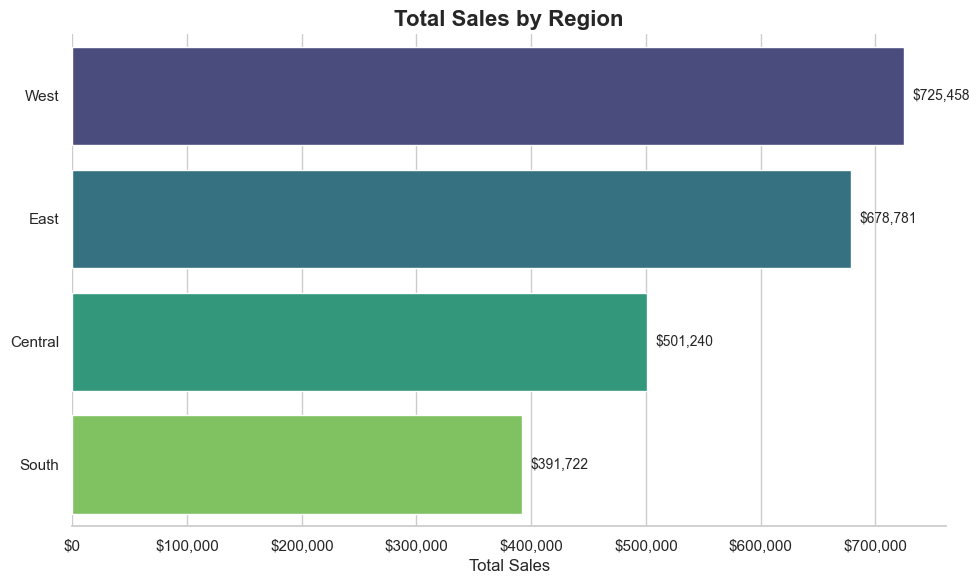

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)


plt.figure(figsize=(10,6))
sns.set_theme(style='whitegrid')
palette = sns.color_palette('viridis', len(region_sales))

# Use horizontal bars for easier label reading
ax = sns.barplot(x=region_sales.values, y=region_sales.index, palette=palette)

# Format x-axis as dollars
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Annotate bars with dollar amounts
max_val = region_sales.values.max()
for i, v in enumerate(region_sales.values):
    ax.text(v + max_val*0.01, i, f'${v:,.0f}', va='center', fontsize=10)

ax.set_title('Total Sales by Region', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales', fontsize=12)
ax.set_ylabel('')

sns.despine(left=True)
plt.tight_layout()
plt.show()

#This shows sales performance across different regions.


#### Step 8: Monthly Sales Trend

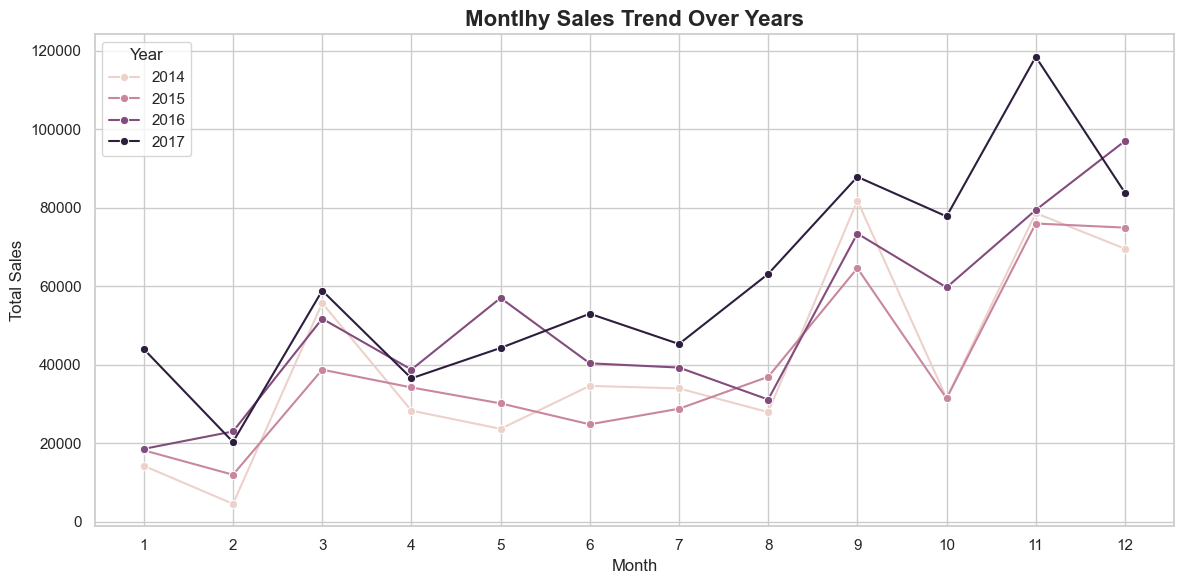

In [41]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().sort_values(ascending= False).reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o')
plt.title('Montlhy Sales Trend Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(range(1,13))
plt.legend(title='Year')
plt.tight_layout()
plt.show()
